### Import Packages & Load .csv Files

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import load_npz
from sklearn.decomposition import TruncatedSVD

CORPUS = pd.read_csv("CORPUS.csv", sep="|")
LIB = pd.read_csv("LIB.csv", sep="|")
VOCAB = pd.read_csv("VOCAB.csv", sep="|")
TFIDF_L2 = load_npz("TFIDF_L2.npz")
TFIDF_L2_doc_ids = pd.read_csv("TFIDF_L2_doc_ids.csv", sep="|") 
TFIDF_L2_terms = pd.read_csv("TFIDF_L2_terms.csv", sep="|")

### PCA Components

In [13]:
# PCA-style model for sparse TFIDF matrix
svd = TruncatedSVD(n_components=10, random_state=2025)
DOCS_PCA = svd.fit_transform(TFIDF_L2)

# terms
terms = TFIDF_L2_terms.iloc[:, 0].astype(str).values

# top terms
comp1 = svd.components_[0]
comp2 = svd.components_[1]

top_pos_1 = terms[np.argsort(comp1)[-5:][::-1]]
top_neg_2 = terms[np.argsort(comp2)[:5]]

print("Top 5 positive terms for first component:", top_pos_1)
print("Top 5 negative terms for second component:", top_neg_2)


Top 5 positive terms for first component: ['people' 'like' 'may' 'money' 'make']
Top 5 negative terms for second component: ['body' 'water' 'like' 'brain' 'feel']


In [ ]:
terms = TFIDF_L2_terms.iloc[:, 0].astype(str).values

# If term list is slightly too long, trim it to matrix width
terms = terms[:TFIDF_L2.shape[1]]

PCA_COMPONENTS = pd.DataFrame(
    svd.components_,
    columns=terms,
    index=[f"PC{i+1}" for i in range(svd.components_.shape[0])]
)

PCA_COMPONENTS.to_csv("PCA_COMPONENTS.csv", sep="|")

### PCA DCM

In [16]:
PCA_DCM = pd.DataFrame(
    DOCS_PCA,
    columns=[f"PC{i+1}" for i in range(DOCS_PCA.shape[1])]
)

PCA_DCM["doc_id"] = TFIDF_L2_doc_ids.iloc[:, 0].values
PCA_DCM.to_csv("PCA_DCM.csv", sep="|", index=False)

### PCA Loadings

In [18]:
PCA_Loadings = PCA_COMPONENTS.copy()
PCA_Loadings.to_csv("PCA_Loadings.csv", sep="|")

### PCA Visualization 1

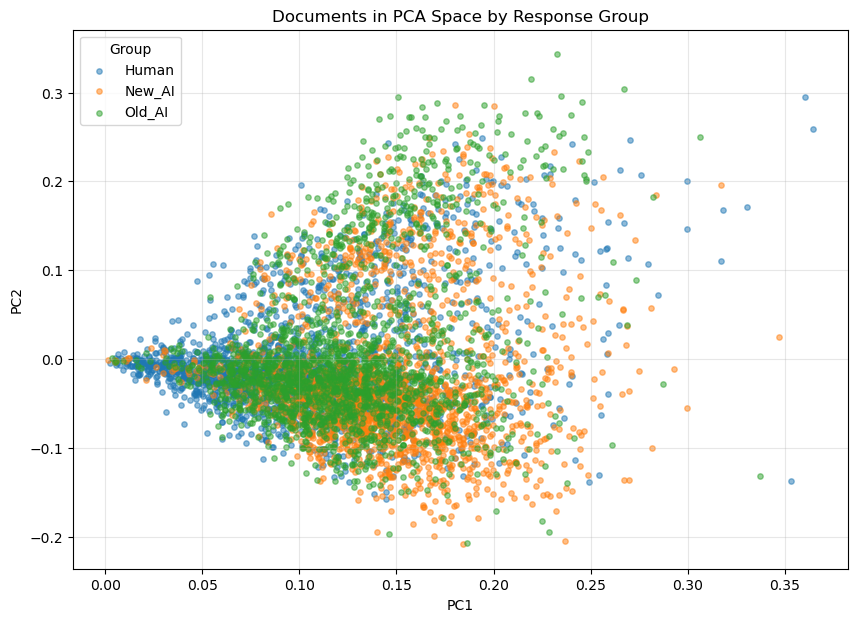

In [19]:
# Make sure doc_id types match
PCA_DCM["doc_id"] = PCA_DCM["doc_id"].astype(int)
LIB["doc_id"] = LIB["doc_id"].astype(int)

# Add metadata to PCA document scores
PCA_PLOT = PCA_DCM.merge(
    LIB[["doc_id", "Group", "Source"]],
    on="doc_id",
    how="left"
)

# Scatterplot: PC1 vs PC2, colored by Group
plt.figure(figsize=(10, 7))

for group, data in PCA_PLOT.groupby("Group"):
    plt.scatter(
        data["PC1"],
        data["PC2"],
        label=group,
        alpha=0.5,
        s=15
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Documents in PCA Space by Response Group")
plt.legend(title="Group")
plt.grid(True, alpha=0.3)
plt.show()

### PCA Visualization 2

### LDA Topic

### LDA Theta

### LDA Phi

### LDA + PCA Visualization

### Sentiment VOCAB_SENT

### Sentiment BOW_SENT

### Sentiment DOC_SENT

### Sentiment Plot

### VOCAB_W2V

### Word2vec tSNE Plot